# Lab 2: Basic Anomaly Detection for Cybersecurity Logs

This notebook implements a small end-to-end anomaly detection workflow for synthetic authentication logs.

The simulated attack patterns are aligned with:
- **MITRE ATT&CK T1110 - Brute Force**
- **MITRE ATT&CK T1078 - Valid Accounts**

The final pipeline includes:
- synthetic dataset generation,
- exploratory data analysis,
- anomaly detection with **Isolation Forest**,
- 2D visualization with **PCA**.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)


## 1. Prepare a Cybersecurity-Related Dataset

The dataset models employee authentication events collected from VPN, SSH, and web portal access logs.
Most events represent normal employee behavior during business hours.
A small minority of events simulate:
- repeated failed login bursts typical for brute-force activity,
- suspicious successful logins from unusual locations and devices that resemble valid-account abuse.


In [2]:
users = [
    "alice", "bob", "carol", "dave", "erin", "frank",
    "grace", "heidi", "ivan", "judy", "mallory", "oscar"
]
user_weights = np.array([0.12, 0.11, 0.09, 0.08, 0.08, 0.08, 0.1, 0.09, 0.08, 0.07, 0.05, 0.05])
user_weights = user_weights / user_weights.sum()

expected_countries = {
    "alice": ["Israel", "Germany"],
    "bob": ["Israel", "United Kingdom"],
    "carol": ["Germany", "Netherlands"],
    "dave": ["Germany", "Poland"],
    "erin": ["United Kingdom", "France"],
    "frank": ["United Kingdom", "Spain"],
    "grace": ["United States", "Canada"],
    "heidi": ["United States", "Canada"],
    "ivan": ["Poland", "Germany"],
    "judy": ["Poland", "Romania"],
    "mallory": ["France", "Belgium"],
    "oscar": ["France", "Spain"],
}
rare_countries = ["Brazil", "Nigeria", "Russia", "Vietnam", "Turkey", "Singapore"]
privileged_users = ["alice", "bob", "grace", "heidi"]

weekday_offsets = [offset for offset in range(28) if (pd.Timestamp("2026-02-01") + pd.Timedelta(days=offset)).dayofweek < 5]
weekend_offsets = [offset for offset in range(28) if (pd.Timestamp("2026-02-01") + pd.Timedelta(days=offset)).dayofweek >= 5]
start_date = pd.Timestamp("2026-02-01")


def sample_day(prefer_weekend=False):
    if prefer_weekend and rng.random() < 0.6:
        return start_date + pd.Timedelta(days=int(rng.choice(weekend_offsets)))
    if not prefer_weekend and rng.random() < 0.82:
        return start_date + pd.Timedelta(days=int(rng.choice(weekday_offsets)))
    return start_date + pd.Timedelta(days=int(rng.integers(0, 28)))


def sample_timestamp(normal=True):
    day = sample_day(prefer_weekend=not normal)
    if normal:
        hour = int(np.clip(rng.normal(13, 2.5), 6, 21))
    else:
        if rng.random() < 0.75:
            hour = int(rng.choice([0, 1, 2, 3, 4, 22, 23]))
        else:
            hour = int(rng.integers(0, 24))
    minute = int(rng.integers(0, 60))
    second = int(rng.integers(0, 60))
    return day + pd.Timedelta(hours=hour, minutes=minute, seconds=second)


def generate_normal_event():
    user = rng.choice(users, p=user_weights)
    timestamp = sample_timestamp(normal=True)
    protocol = rng.choice(["vpn", "web_portal", "ssh"], p=[0.45, 0.4, 0.15])
    device_type = rng.choice(["managed_laptop", "desktop", "mobile"], p=[0.68, 0.2, 0.12])
    source_country = rng.choice(expected_countries[user], p=[0.87, 0.13])

    failed_attempts_1h = int(np.clip(np.rint(rng.normal(0.7, 0.9)), 0, 4))
    login_attempts_10m = int(np.clip(failed_attempts_1h + 1 + rng.integers(0, 2), 1, 5))
    session_duration_sec = int(np.clip(rng.gamma(shape=3.2, scale=700), 180, 14400))
    bytes_sent = int(np.clip(rng.lognormal(mean=9.5, sigma=0.5), 2_000, 300_000))
    bytes_received = int(np.clip(rng.lognormal(mean=10.2, sigma=0.55), 3_000, 500_000))

    return {
        "timestamp": timestamp,
        "user": user,
        "source_country": source_country,
        "protocol": protocol,
        "device_type": device_type,
        "failed_attempts_1h": failed_attempts_1h,
        "login_attempts_10m": login_attempts_10m,
        "session_duration_sec": session_duration_sec,
        "bytes_sent": bytes_sent,
        "bytes_received": bytes_received,
        "attack_type": "normal",
        "is_attack": 0,
    }


def generate_brute_force_event():
    user = rng.choice(privileged_users, p=[0.35, 0.25, 0.2, 0.2])
    timestamp = sample_timestamp(normal=False)
    protocol = rng.choice(["ssh", "web_portal"], p=[0.8, 0.2])
    source_country = rng.choice(rare_countries)

    failed_attempts_1h = int(rng.integers(12, 36))
    login_attempts_10m = int(rng.integers(failed_attempts_1h, failed_attempts_1h + 12))
    session_duration_sec = int(rng.integers(10, 240))
    bytes_sent = int(rng.integers(200, 4_000))
    bytes_received = int(rng.integers(300, 6_000))

    return {
        "timestamp": timestamp,
        "user": user,
        "source_country": source_country,
        "protocol": protocol,
        "device_type": "unknown_host",
        "failed_attempts_1h": failed_attempts_1h,
        "login_attempts_10m": login_attempts_10m,
        "session_duration_sec": session_duration_sec,
        "bytes_sent": bytes_sent,
        "bytes_received": bytes_received,
        "attack_type": "brute_force",
        "is_attack": 1,
    }


def generate_valid_account_abuse_event():
    user = rng.choice(privileged_users, p=[0.3, 0.25, 0.25, 0.2])
    timestamp = sample_timestamp(normal=False)
    source_country = rng.choice(rare_countries)
    protocol = rng.choice(["vpn", "web_portal"], p=[0.75, 0.25])

    failed_attempts_1h = int(rng.integers(0, 3))
    login_attempts_10m = int(rng.integers(1, 4))
    session_duration_sec = int(rng.integers(4_000, 20_000))
    bytes_sent = int(np.clip(rng.lognormal(mean=12.2, sigma=0.45), 200_000, 3_500_000))
    bytes_received = int(np.clip(rng.lognormal(mean=12.5, sigma=0.45), 250_000, 5_000_000))

    return {
        "timestamp": timestamp,
        "user": user,
        "source_country": source_country,
        "protocol": protocol,
        "device_type": "new_device",
        "failed_attempts_1h": failed_attempts_1h,
        "login_attempts_10m": login_attempts_10m,
        "session_duration_sec": session_duration_sec,
        "bytes_sent": bytes_sent,
        "bytes_received": bytes_received,
        "attack_type": "valid_account_abuse",
        "is_attack": 1,
    }


normal_events = [generate_normal_event() for _ in range(4_850)]
brute_force_events = [generate_brute_force_event() for _ in range(100)]
valid_account_events = [generate_valid_account_abuse_event() for _ in range(50)]

df = pd.DataFrame(normal_events + brute_force_events + valid_account_events)
df = df.sample(frac=1.0, random_state=RANDOM_SEED).reset_index(drop=True)
df["hour"] = df["timestamp"].dt.hour
df["day_name"] = df["timestamp"].dt.day_name()

print(f"Dataset shape: {df.shape}")
print(f"Attack ratio: {df['is_attack'].mean():.2%}")
display(df.head())


Dataset shape: (5000, 14)
Attack ratio: 3.00%


,timestamp,user,source_country,protocol,device_type,failed_attempts_1h,login_attempts_10m,session_duration_sec,bytes_sent,bytes_received,attack_type,is_attack,hour,day_name
0,2026-02-02 13:13:28,heidi,United States,web_portal,managed_laptop,0,2,3126,13217,19680,normal,0,13,Monday
1,2026-02-06 12:30:32,grace,United States,web_portal,mobile,0,1,1949,15032,28688,normal,0,12,Friday
2,2026-02-20 17:32:37,ivan,Poland,vpn,managed_laptop,1,3,3684,16258,11528,normal,0,17,Friday
3,2026-02-06 14:21:27,bob,Israel,ssh,managed_laptop,0,2,1733,39746,44423,normal,0,14,Friday
4,2026-02-06 11:12:12,ivan,Germany,vpn,managed_laptop,1,3,1255,11354,16040,normal,0,11,Friday


In [3]:
class_distribution = df["attack_type"].value_counts().rename_axis("attack_type").reset_index(name="count")
display(class_distribution)

print("Anomalies are a small minority, which is appropriate for Isolation Forest.")


,attack_type,count
0,normal,4850
1,brute_force,100
2,valid_account_abuse,50


Anomalies are a small minority, which is appropriate for Isolation Forest.


## 2. Exploratory Data Analysis (EDA)


In [4]:
num_rows, num_features = df.shape
print(f"Number of rows: {num_rows}")
print(f"Number of features: {num_features}")
print("\nClass distribution:")
print(df["attack_type"].value_counts())
print("\nMissing values per column:")
print(df.isna().sum())


Number of rows: 5000
Number of features: 14

Class distribution:
attack_type
normal                 4850
brute_force             100
valid_account_abuse      50
Name: count, dtype: int64

Missing values per column:
timestamp               0
user                    0
source_country          0
protocol                0
device_type             0
failed_attempts_1h      0
login_attempts_10m      0
session_duration_sec    0
bytes_sent              0
bytes_received          0
attack_type             0
is_attack               0
hour                    0
day_name                0
dtype: int64


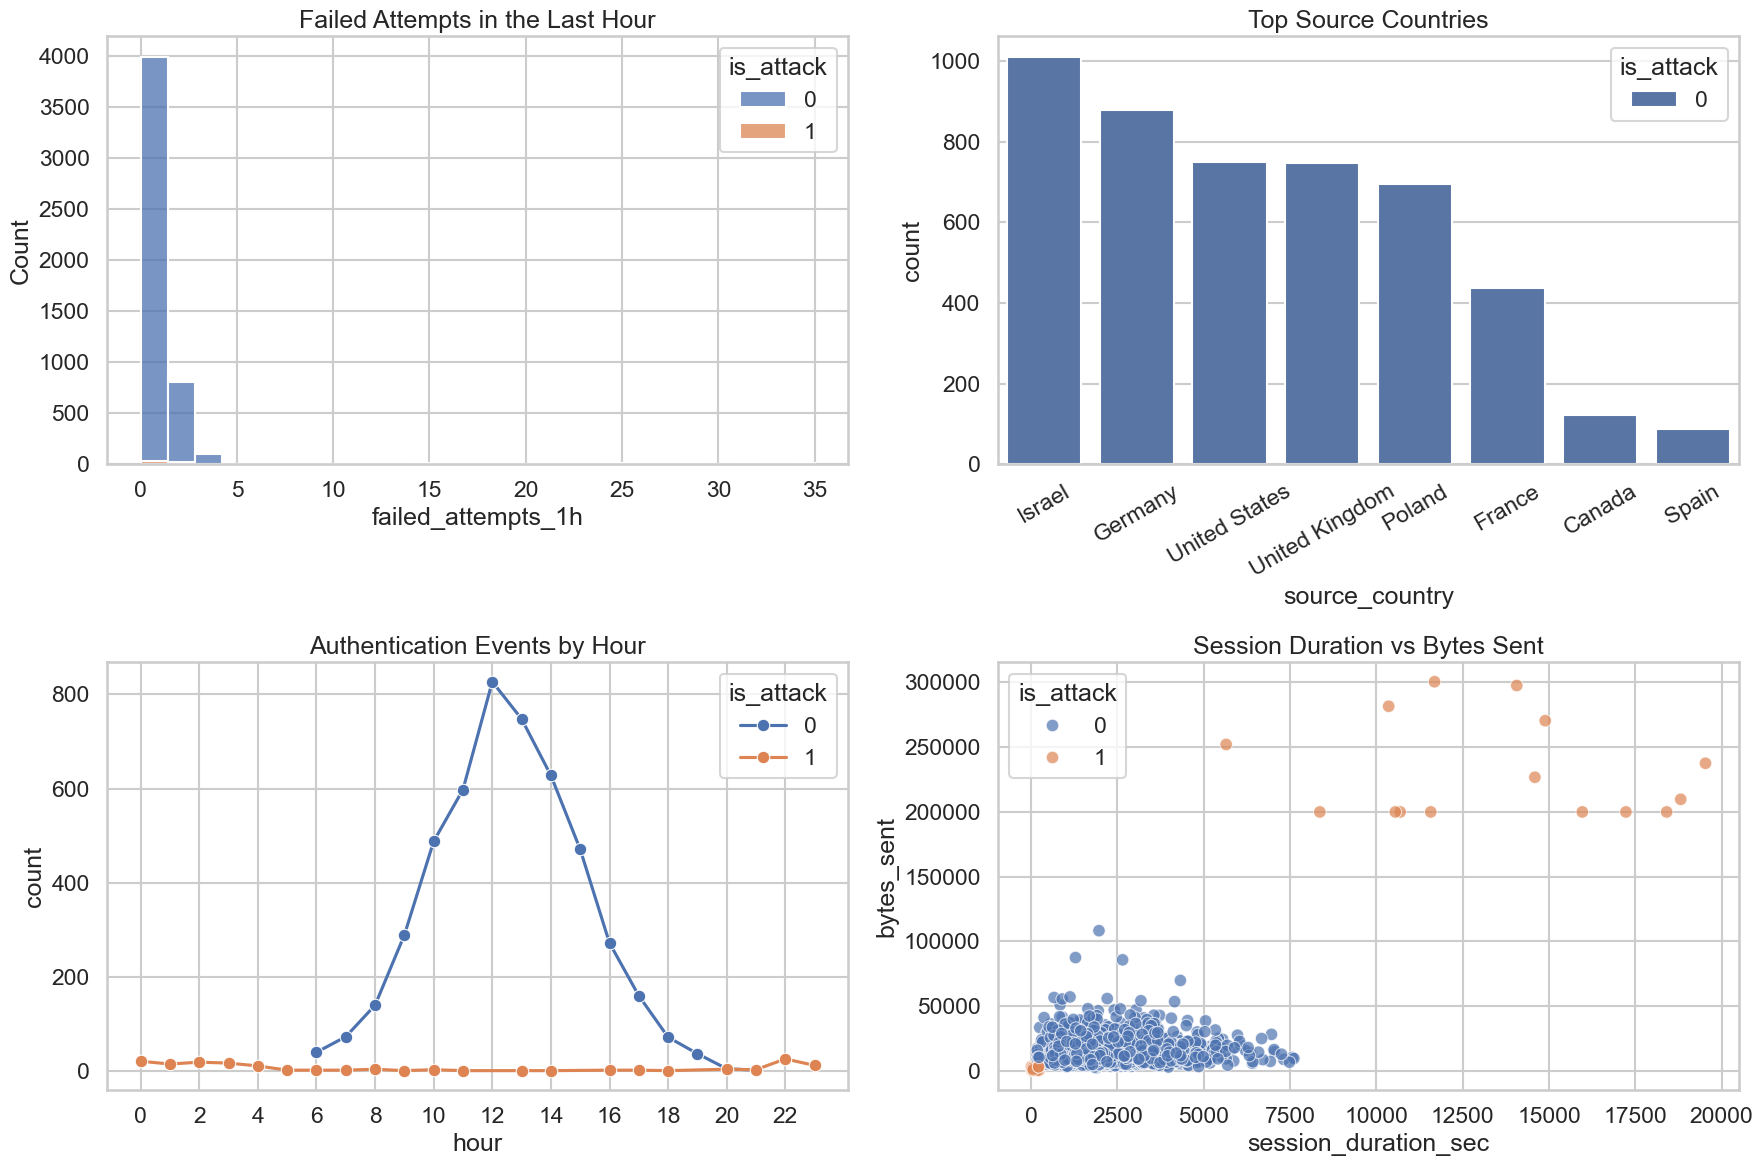

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.histplot(data=df, x="failed_attempts_1h", hue="is_attack", bins=25, multiple="stack", ax=axes[0, 0])
axes[0, 0].set_title("Failed Attempts in the Last Hour")
axes[0, 0].set_xlabel("failed_attempts_1h")

top_countries = df["source_country"].value_counts().head(8).index
sns.countplot(
    data=df[df["source_country"].isin(top_countries)],
    x="source_country",
    hue="is_attack",
    order=top_countries,
    ax=axes[0, 1],
)
axes[0, 1].set_title("Top Source Countries")
axes[0, 1].tick_params(axis="x", rotation=30)

hourly_counts = df.groupby(["hour", "is_attack"]).size().reset_index(name="count")
sns.lineplot(data=hourly_counts, x="hour", y="count", hue="is_attack", marker="o", ax=axes[1, 0])
axes[1, 0].set_title("Authentication Events by Hour")
axes[1, 0].set_xticks(range(0, 24, 2))

sample = df.sample(2_000, random_state=RANDOM_SEED)
sns.scatterplot(
    data=sample,
    x="session_duration_sec",
    y="bytes_sent",
    hue="is_attack",
    alpha=0.7,
    ax=axes[1, 1],
)
axes[1, 1].set_title("Session Duration vs Bytes Sent")
axes[1, 1].set_xlabel("session_duration_sec")
axes[1, 1].set_ylabel("bytes_sent")

plt.tight_layout()
plt.show()


### Analytical Summary

Normal authentication activity is concentrated around business hours and comes mostly from each user's expected country set.
Most benign sessions contain very few failed attempts, short login bursts, and moderate traffic volumes.
The two synthetic anomaly families break those patterns in different ways: brute-force events create many failed attempts in short time windows, while valid-account abuse looks more subtle and is driven by unusual locations, devices, and very large sessions.
Based on these patterns, we expect Isolation Forest to detect the night-time login bursts easily and to flag at least part of the unusual successful sessions as outliers near the edges of the feature space.


## 3. Apply an Anomaly Detection Model

The primary model required by the assignment is **Isolation Forest**.
We will preprocess the mixed feature set by:
- scaling numeric features,
- one-hot encoding categorical features,
- fitting the detector on the full dataset with the true anomaly ratio used as the contamination level.


In [6]:
numeric_features = [
    "hour",
    "failed_attempts_1h",
    "login_attempts_10m",
    "session_duration_sec",
    "bytes_sent",
    "bytes_received",
]
categorical_features = ["user", "source_country", "protocol", "device_type", "day_name"]

X_raw = df[numeric_features + categorical_features]
y_true = df["is_attack"].to_numpy()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    sparse_threshold=0,
)

X_processed = preprocessor.fit_transform(X_raw)
if hasattr(X_processed, "toarray"):
    X_processed = X_processed.toarray()
X_processed = np.asarray(X_processed, dtype=float)

model = IsolationForest(
    n_estimators=300,
    contamination=float(y_true.mean()),
    random_state=RANDOM_SEED,
)
model.fit(X_processed)

df["anomaly_score"] = -model.decision_function(X_processed)
df["iforest_pred"] = (model.predict(X_processed) == -1).astype(int)
df["predicted_label"] = np.where(df["iforest_pred"] == 1, "anomalous", "normal")

display(
    df[[
        "timestamp",
        "user",
        "source_country",
        "protocol",
        "failed_attempts_1h",
        "session_duration_sec",
        "attack_type",
        "predicted_label",
        "anomaly_score",
    ]].head()
)


,timestamp,user,source_country,protocol,failed_attempts_1h,session_duration_sec,attack_type,predicted_label,anomaly_score
0,2026-02-02 13:13:28,heidi,United States,web_portal,0,3126,normal,normal,-0.088908
1,2026-02-06 12:30:32,grace,United States,web_portal,0,1949,normal,normal,-0.059437
2,2026-02-20 17:32:37,ivan,Poland,vpn,1,3684,normal,normal,-0.066051
3,2026-02-06 14:21:27,bob,Israel,ssh,0,1733,normal,normal,-0.070558
4,2026-02-06 11:12:12,ivan,Germany,vpn,1,1255,normal,normal,-0.080764


Isolation Forest detected 150 anomalies out of 5000 events.

Confusion table:
predicted_label      anomalous  normal
attack_type                           
brute_force                 99       1
normal                       1    4849
valid_account_abuse         50       0

Metrics:


,metric,value
0,accuracy,0.999600
1,precision,0.993333
2,recall,0.993333


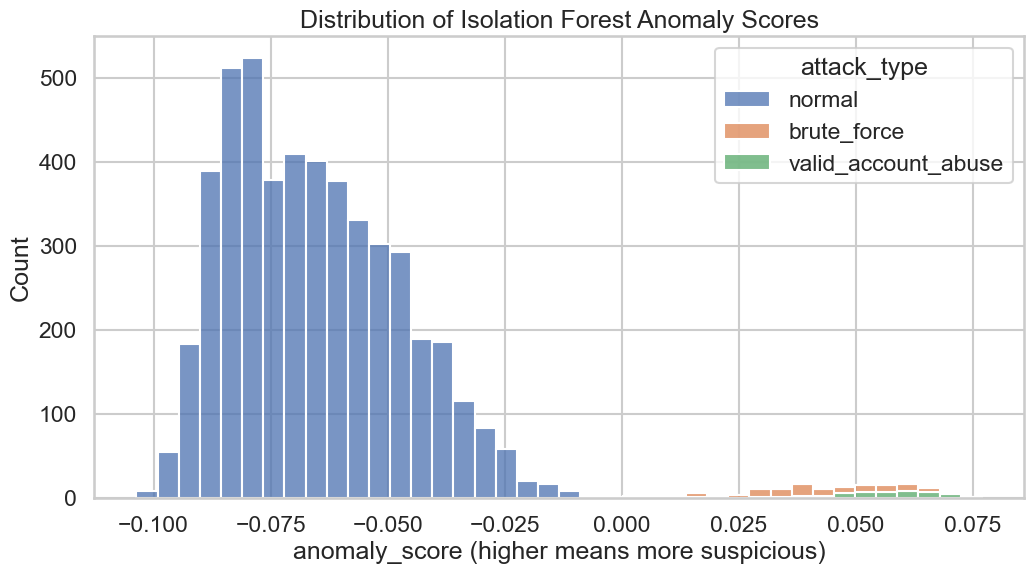

Top 10 most suspicious events:


,timestamp,user,source_country,protocol,device_type,failed_attempts_1h,login_attempts_10m,session_duration_sec,bytes_sent,attack_type,anomaly_score
1158,2026-02-07 23:26:36,grace,Vietnam,web_portal,new_device,0,3,19532,237565,valid_account_abuse,0.076927
927,2026-02-01 21:35:57,bob,Brazil,vpn,new_device,1,2,17228,200000,valid_account_abuse,0.071391
428,2026-02-28 00:50:05,heidi,Nigeria,vpn,new_device,2,1,15779,325361,valid_account_abuse,0.070853
939,2026-02-21 00:54:19,grace,Turkey,vpn,new_device,0,1,10239,200000,valid_account_abuse,0.070249
4075,2026-02-14 22:32:55,alice,Russia,web_portal,new_device,2,1,18814,209731,valid_account_abuse,0.069837
575,2026-02-22 01:56:03,alice,Brazil,ssh,unknown_host,33,37,199,1950,brute_force,0.068837
4721,2026-02-21 20:14:37,alice,Turkey,vpn,new_device,2,3,14066,297626,valid_account_abuse,0.068456
2430,2026-02-14 01:12:20,bob,Vietnam,vpn,new_device,1,3,19284,269044,valid_account_abuse,0.067835
2856,2026-02-15 22:00:34,alice,Brazil,ssh,unknown_host,31,41,93,325,brute_force,0.067397
2822,2026-02-28 00:49:31,heidi,Brazil,web_portal,new_device,2,2,9122,277864,valid_account_abuse,0.066357


In [7]:
metrics_table = pd.DataFrame(
    {
        "metric": ["accuracy", "precision", "recall"],
        "value": [
            accuracy_score(y_true, df["iforest_pred"]),
            precision_score(y_true, df["iforest_pred"], zero_division=0),
            recall_score(y_true, df["iforest_pred"], zero_division=0),
        ],
    }
)

detected_anomalies = int(df["iforest_pred"].sum())
print(f"Isolation Forest detected {detected_anomalies} anomalies out of {len(df)} events.")
print("\nConfusion table:")
print(pd.crosstab(df["attack_type"], df["predicted_label"]))
print("\nMetrics:")
display(metrics_table)

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x="anomaly_score", hue="attack_type", bins=40, multiple="stack")
plt.title("Distribution of Isolation Forest Anomaly Scores")
plt.xlabel("anomaly_score (higher means more suspicious)")
plt.show()

print("Top 10 most suspicious events:")
display(
    df.nlargest(10, "anomaly_score")[
        [
            "timestamp",
            "user",
            "source_country",
            "protocol",
            "device_type",
            "failed_attempts_1h",
            "login_attempts_10m",
            "session_duration_sec",
            "bytes_sent",
            "attack_type",
            "anomaly_score",
        ]
    ]
)


## 4. Visualize Anomalies on a 2D Projection

We use **PCA** as the baseline dimensionality-reduction method.
The projection is computed from the same preprocessed feature matrix that was used by Isolation Forest.


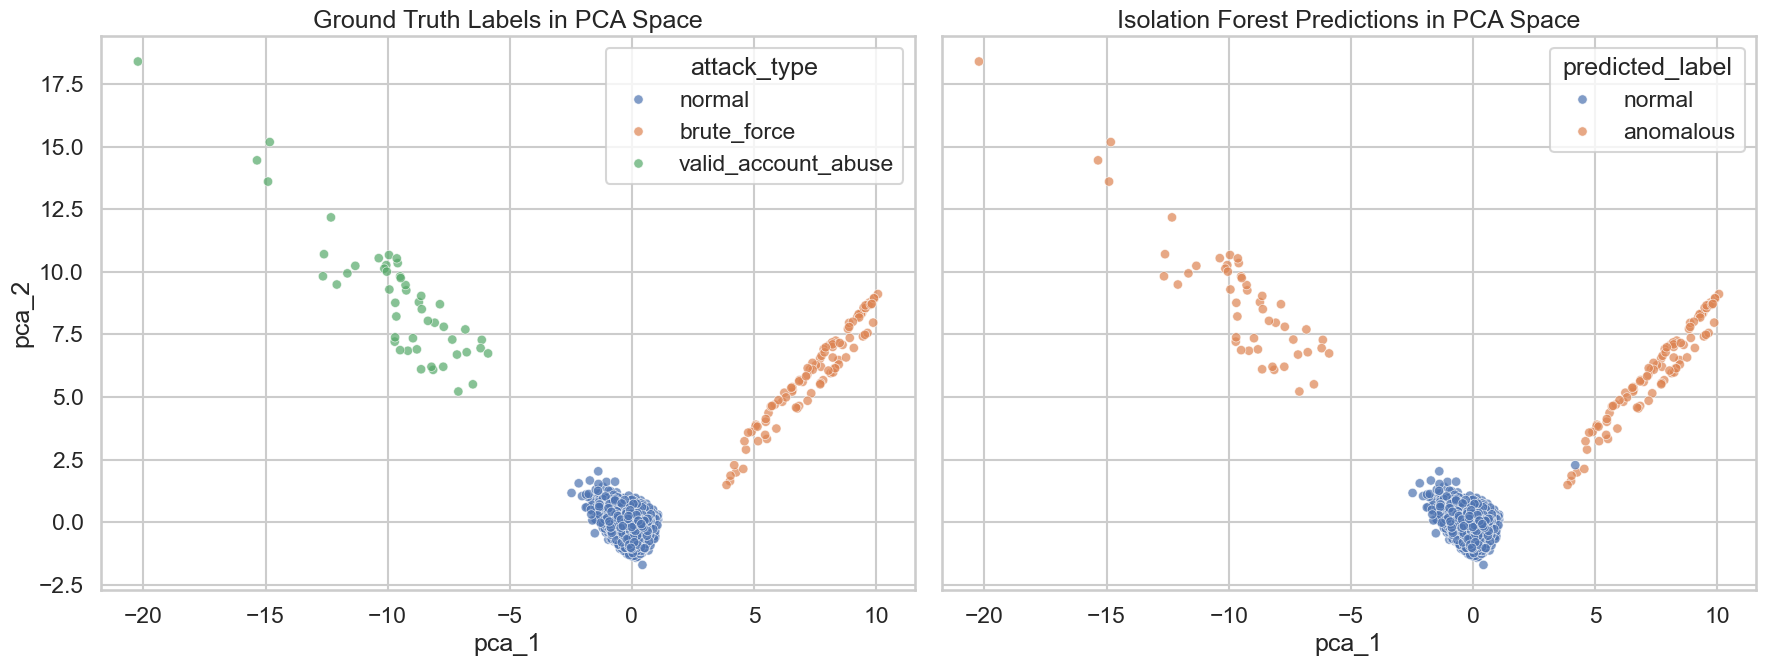

Explained variance captured by the first two PCA components: 43.84%


In [8]:
pca = PCA(n_components=2)
projection = pca.fit_transform(X_processed)

df["pca_1"] = projection[:, 0]
df["pca_2"] = projection[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=True, sharey=True)

sns.scatterplot(
    data=df,
    x="pca_1",
    y="pca_2",
    hue="attack_type",
    alpha=0.7,
    s=45,
    ax=axes[0],
)
axes[0].set_title("Ground Truth Labels in PCA Space")

sns.scatterplot(
    data=df,
    x="pca_1",
    y="pca_2",
    hue="predicted_label",
    alpha=0.7,
    s=45,
    ax=axes[1],
)
axes[1].set_title("Isolation Forest Predictions in PCA Space")

plt.tight_layout()
plt.show()

explained_variance = pca.explained_variance_ratio_.sum()
print(f"Explained variance captured by the first two PCA components: {explained_variance:.2%}")


### 2D Projection Interpretation

The PCA view shows a dense region of normal employee activity surrounded by a smaller number of isolated points and sparse groups.
The brute-force events are expected to sit far away from the central cluster because their failure counts and login burst intensity are extreme.
The valid-account-abuse events can overlap more with normal traffic, but many still move toward the edges of the projection due to unusual countries, new devices, and very large session volumes.


## Conclusion

This notebook demonstrates a complete anomaly detection workflow for cybersecurity logs.
The synthetic data preserves a realistic imbalance between normal and suspicious events, the EDA highlights the dominant normal behavior, and Isolation Forest identifies outliers without relying on the labels during fitting.
In practice, the strongest signals come from failed-login bursts, off-hours activity, unusual geolocation patterns, and large sessions from new devices.
